In [1]:
# Installs & imports
!pip install albumentationsx

import os
import cv2
import copy
import time
import torch
print("Version PyTorch :", torch.__version__)
import random
import numpy as np
import torch.nn as nn
import albumentations as A
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchmetrics.classification import BinaryAUROC, BinaryFBetaScore, BinaryJaccardIndex, BinaryRecall

print("Imports ok.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.4/109.4 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.6/85.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 551.4/551.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.3/472.3 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 105.2 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.4
    Uninstalling pydantic_core-2.41.4:
      Successfully uninstalled pydantic_core-2.41.4
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.3
    Uninstalling pydantic-2.12.3:
      Successfully uninstalled pydantic-2.12.3
  Attempting uni

In [2]:
# Reproductibility
def seed_everything(seed):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def make_generator(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator

In [3]:
# Data processing
class DataProcessor:

    def __init__(self, preprocessing_fn, augmentation_transform, target_image_size):
        self.preprocessing_fn = preprocessing_fn
        self.transform = augmentation_transform
        self.target_size = target_image_size
    
    def read(self, image_path, mask_path):
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if mask_path is not None:
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = (mask > 127).astype(np.uint8)
            return image, mask
        else:
            return image
    
    def resize_and_pad(self, image, mask):
        height, width = image.shape[:2]
        scale = min(self.target_size / height, self.target_size / width)
        scaled_height = int(np.round(height * scale))
        scaled_width = int(np.round(width * scale))
        resized_image = cv2.resize(image, (scaled_width, scaled_height), interpolation=cv2.INTER_LINEAR)
        top_padding = (self.target_size - scaled_height) // 2
        bottom_padding = self.target_size - scaled_height - top_padding
        left_padding = (self.target_size - scaled_width) // 2
        right_padding = self.target_size - scaled_width - left_padding
        padded_image = cv2.copyMakeBorder(resized_image, top_padding, bottom_padding, left_padding, right_padding, borderType=cv2.BORDER_CONSTANT, value=0)
        data_dict = {
            "base_height": height,
            "base_width": width,
            "scale": scale,
            "scaled_height": scaled_height,
            "scaled_width": scaled_width,
            "top_padding": top_padding,
            "bottom_padding": bottom_padding,
            "left_padding": left_padding,
            "right_padding": right_padding
        }
        if mask is not None:
            resized_mask = cv2.resize(mask, (scaled_width, scaled_height), interpolation=cv2.INTER_NEAREST)
            padded_mask = cv2.copyMakeBorder(resized_mask, top_padding, bottom_padding, left_padding, right_padding, borderType=cv2.BORDER_CONSTANT, value=0)
            return padded_image, padded_mask, data_dict
        else:
            return padded_image, data_dict
    
    def preprocess_image(self, image):
        return self.preprocessing_fn(image)
    
    def augment(self, preprocessed_image, mask):
        augmented = self.transform(image=preprocessed_image, mask=mask)
        image = augmented["image"].float() / 255.0
        mask = augmented["mask"].unsqueeze(0).float()
        return image, mask

class TrainingDataset(Dataset):

    def __init__(self, images_dir, masks_dir, data_processor):
        self.images_paths = sorted([entry.path for entry in os.scandir(images_dir)])
        self.masks_paths = sorted([entry.path for entry in os.scandir(masks_dir)])
        assert(len(self.images_paths) == len(self.masks_paths))
        self.data_processor = data_processor

    def __len__(self):
        return len(self.masks_paths)
    
    def __getitem__(self, index):
        image, mask = self.data_processor.read(self.images_paths[index], self.masks_paths[index])
        image, mask, data_dict = self.data_processor.resize_and_pad(image, mask)
        image = self.data_processor.preprocess_image(image)
        image, mask = self.data_processor.augment(image, mask)
        return {"image": image, "mask": mask, "data_dict": data_dict}

class PredictionsDataset(Dataset):

    def __init__(self, images_dir, data_processor):
        super().__init__()
        self.images_paths = [entry.path for entry in os.scandir(images_dir)] # No need to sort
        self.data_processor = data_processor
    
    def __len__(self):
        return len(self.images_paths)
    
    def __getitem__(self, index):
        image = self.data_processor.read(self.images_paths[index], None)
        image_name = os.path.basename(self.images_paths[index])
        image, data_dict = self.data_processor.resize_and_pad(image, None)
        image = self.data_processor.preprocess_image(image)
        image = torch.from_numpy(image).unsqueeze(0).float() / 255.0
        return {"image": image, "image_name": image_name, "data_dict": data_dict}

In [4]:
# Data loading utilities
def make_datasets(images_dir, masks_dir, predictions_dir, data_processor, validation_size, generator):
    training_dataset = TrainingDataset(images_dir, masks_dir, data_processor)
    training_dataset, validation_dataset = random_split(training_dataset, lengths=[1.0 - validation_size, validation_size], generator=generator)
    predictions_dataset = PredictionsDataset(predictions_dir, data_processor)
    return training_dataset, validation_dataset, predictions_dataset

def make_dataloaders(train_dataset, val_dataset, preds_dataset, train_batch_size, generator):
    train_loader = DataLoader(
        train_dataset,
        train_batch_size,
        shuffle=True,
        generator=generator
    )
    val_loader = DataLoader(
        val_dataset,
        train_batch_size,
        shuffle=False,
        generator=generator
    )
    predict_loader = DataLoader(preds_dataset, batch_size=1, shuffle=False)
    return train_loader, val_loader, predict_loader

In [5]:
# Training utilities
def train_model_one_epoch(model, train_loader, optimizer, criterion, device):
    model.train()
    avg_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        images, masks = batch["image"], batch["mask"]
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        avg_loss += loss.item()
        loss.backward()
        optimizer.step()
    return avg_loss / len(train_loader)

def evaluate_model(model, val_loader, criterion, metrics, device):
    model.eval()
    for metric in metrics:
        metric.reset()
    avg_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            images, masks = batch["image"], batch["mask"]
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            avg_loss += loss.item()
            for metric in metrics:
                metric.update(outputs, masks)
    metrics_dict = {metric._get_name(): metric.compute() for metric in metrics}
    return avg_loss / len(val_loader), metrics_dict

def train_model(model, train_loader, val_loader, optimizer, criterion, metrics, epochs, patience, device):
    model.to(device)
    best_model_dict = copy.deepcopy(model.state_dict())
    metrics = [metric.to(device) for metric in metrics]
    all_val_metrics_dict = {metric._get_name(): [] for metric in metrics}
    train_losses = []
    val_losses = []
    best_val_loss = torch.inf
    patience_counter = 0
    start_time = time.time()
    for epoch in range(epochs):
        train_loss = train_model_one_epoch(model, train_loader, optimizer, criterion, device)
        train_losses.append(train_loss)
        val_loss, val_metrics_dict = evaluate_model(model, val_loader, criterion, metrics, device)
        val_losses.append(val_loss)
        for k, v in val_metrics_dict.items():
            all_val_metrics_dict[k].append(v)
        if (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Training loss = {train_loss}, validation loss = {val_loss}")
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_dict = copy.deepcopy(model.state_dict())
            print(f"New best validation loss = {best_val_loss:.4f} reached on epoch {epoch+1}.")
        else:
            patience_counter += 1
        if patience_counter > patience:
            print(f"Validation loss did not improve over the last {patience} epochs, early stopping at epoch {epoch}.")
            break
    training_time = time.time() - start_time
    model.load_state_dict(best_model_dict)
    return model, train_losses, val_losses, all_val_metrics_dict, training_time

In [6]:
# Predictions utilities
def resize_to_base(predicted_mask, data_dict):
        top_padding = int(data_dict["top_padding"][0])
        left_padding = int(data_dict["left_padding"][0])
        scaled_height = int(data_dict["scaled_height"][0])
        scaled_width = int(data_dict["scaled_width"][0])
        base_height = int(data_dict["base_height"][0])
        base_width = int(data_dict["base_width"][0])
        predicted_mask = predicted_mask[top_padding : top_padding + scaled_height, left_padding : left_padding + scaled_width]
        predicted_mask = cv2.resize(predicted_mask, (base_width, base_height), interpolation=cv2.INTER_NEAREST)
        return predicted_mask

def predict_masks(model, predict_loader, predictions_masks_dir, device):
    for batch in predict_loader: # Batch size of 1
        image, image_name, data_dict = batch["image"], batch["image_name"][0], batch["data_dict"]
        image = image.to(device)
        output_mask = model(image).detach()[0, 0]
        output_mask = (torch.sigmoid(output_mask) >= 0.5).cpu().numpy().astype(np.uint8)
        resized_mask = resize_to_base(output_mask, data_dict) * 255
        cv2.imwrite(os.path.join(predictions_masks_dir, f"Mask_{image_name}" + ".png"), resized_mask)

In [7]:
# UNet
class DoubleConvolution(nn.Module):

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_features=out_channels),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        return self.double_conv(x)

class UNet(nn.Module):

    def __init__(self, in_channels):
        super().__init__()

        # Max pool
        self.max_pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Downsampling layers
        self.down_1 = DoubleConvolution(in_channels=in_channels, out_channels=64)
        self.down_2 = DoubleConvolution(in_channels=64, out_channels=128)
        self.down_3 = DoubleConvolution(in_channels=128, out_channels=256)
        self.down_4 = DoubleConvolution(in_channels=256, out_channels=512)
        self.down_5 = DoubleConvolution(in_channels=512, out_channels=1024)

        # Upsampling layers
        self.up_transpose_1 = nn.ConvTranspose2d(in_channels=1024, out_channels=512, kernel_size=2, stride=2)
        self.up_conv_1 = DoubleConvolution(in_channels=1024, out_channels=512)
        self.up_transpose_2 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        self.up_conv_2 = DoubleConvolution(in_channels=512, out_channels=256)
        self.up_transpose_3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.up_conv_3 = DoubleConvolution(in_channels=256, out_channels=128)
        self.up_transpose_4 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.up_conv_4 = DoubleConvolution(in_channels=128, out_channels=64)
        self.out = nn.Conv2d(in_channels=64, out_channels=1, kernel_size=1)

    def forward(self, x):
        # Downsampling
        down_1 = self.down_1(x)
        max_pool_1 = self.max_pool(down_1)
        down_2 = self.down_2(max_pool_1)
        max_pool_2 = self.max_pool(down_2)
        down_3 = self.down_3(max_pool_2)
        max_pool_3 = self.max_pool(down_3)
        down_4 = self.down_4(max_pool_3)
        max_pool_4 = self.max_pool(down_4)
        down_5 = self.down_5(max_pool_4)
        
        # Upsampling
        up_1 = self.up_transpose_1(down_5)
        x = self.up_conv_1(torch.cat([down_4, up_1], dim=1))
        up_2 = self.up_transpose_2(x)
        x = self.up_conv_2(torch.cat([down_3, up_2], dim=1))
        up_3 = self.up_transpose_3(x)
        x = self.up_conv_3(torch.cat([down_2, up_3], dim=1))
        up_4 = self.up_transpose_4(x)
        x = self.up_conv_4(torch.cat([down_1, up_4], dim=1))
        out = self.out(x)
        return out

In [8]:
# Losses
class DiceLoss(nn.Module):

    def __init__(self, smoothing_factor=1e-6):
        super().__init__()
        self.smoothing_factor = smoothing_factor
    
    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.flatten(1)
        targets = targets.flatten(1)
        intersection = (preds * targets).sum(dim=1)
        union = preds.sum() + targets.sum(dim=1)
        dice = (2 * intersection + self.smoothing_factor) / (union + self.smoothing_factor)
        return 1 - dice.mean()

class ComboLoss(nn.Module):

    def __init__(self, dice_weight, bce_pos_weight=None):
        super().__init__()
        self.dice_loss = DiceLoss()
        self.dice_weight = dice_weight
        self.bce_pos_weight = torch.tensor(bce_pos_weight) if bce_pos_weight is not None else None
    
    def forward(self, preds, targets):
        dice = self.dice_loss(preds, targets)
        bce = F.binary_cross_entropy_with_logits(preds, targets, pos_weight=self.bce_pos_weight)
        return self.dice_weight * dice + (1 - self.dice_weight) * bce

In [9]:
# Data loading & Training
SEED = 24
seed_everything(SEED)

datasets_generator = make_generator(SEED)
dataloaders_generator = make_generator(SEED)

training_images_dir = "/kaggle/input/datasets/tomcoutance/deep-retinal-segmentation/Training/Images/"
training_masks_dir = "/kaggle/input/datasets/tomcoutance/deep-retinal-segmentation/Training/Masks/"
predictions_images_dir = "/kaggle/input/datasets/tomcoutance/deep-retinal-segmentation/Predictions/Images/"

def image_preprocessing(image):
    green_channel = image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=5)
    green_clahe = clahe.apply(green_channel)
    return green_clahe

augmentation_transform = A.Compose([
    A.SquareSymmetry(),
    A.ToTensorV2()
], seed=SEED)

data_processor = DataProcessor(image_preprocessing, augmentation_transform, target_image_size=512)

train_dataset, val_dataset, predict_dataset = make_datasets(
    training_images_dir,
    training_masks_dir,
    predictions_images_dir,
    data_processor,
    validation_size=0.1,
    generator=datasets_generator
)

train_loader, val_loader, predict_loader = make_dataloaders(
    train_dataset,
    val_dataset,
    predict_dataset,
    train_batch_size=4,
    generator=dataloaders_generator
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet(in_channels=1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = ComboLoss(dice_weight=0.5, bce_pos_weight=5)
metrics = [BinaryJaccardIndex(), BinaryAUROC(), BinaryFBetaScore(beta=2.0), BinaryRecall()]

trained_model, train_losses, val_losses, metrics_dict, training_time = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    metrics,
    epochs=100,
    patience=10,
    device=DEVICE
)

New best validation loss = 0.7389 reached on epoch 1.
New best validation loss = 0.6939 reached on epoch 2.
New best validation loss = 0.6781 reached on epoch 3.
New best validation loss = 0.6615 reached on epoch 4.
Epoch 5/100 | Training loss = 0.6520742895426573, validation loss = 0.6381805042425791
New best validation loss = 0.6382 reached on epoch 5.
New best validation loss = 0.6246 reached on epoch 7.
New best validation loss = 0.6183 reached on epoch 8.
New best validation loss = 0.6181 reached on epoch 9.
Epoch 10/100 | Training loss = 0.6093827585379282, validation loss = 0.6030086874961853
New best validation loss = 0.6030 reached on epoch 10.
New best validation loss = 0.6017 reached on epoch 12.
New best validation loss = 0.5909 reached on epoch 13.
New best validation loss = 0.5841 reached on epoch 14.
Epoch 15/100 | Training loss = 0.582576987919984, validation loss = 0.5782241026560465
New best validation loss = 0.5782 reached on epoch 15.
New best validation loss = 0.56

In [10]:
print("Training time (s):", training_time)

Training time (s): 4308.074701547623


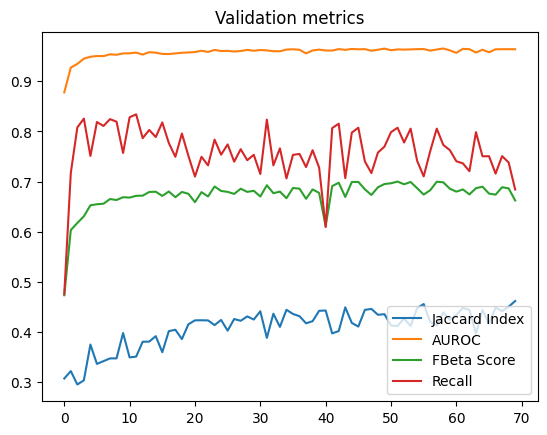

In [11]:
jaccard = [j.item() for j in metrics_dict["BinaryJaccardIndex"]]
auroc = [a.item() for a in metrics_dict["BinaryAUROC"]]
fbeta = [f.item() for f in metrics_dict["BinaryFBetaScore"]]
recall = [r.item() for r in metrics_dict["BinaryRecall"]]
plt.plot(jaccard, label="Jaccard Index")
plt.plot(auroc, label="AUROC")
plt.plot(fbeta, label="FBeta Score")
plt.plot(recall, label="Recall")
plt.title("Validation metrics")
plt.legend()

In [12]:
predictions_masks_dir = "/kaggle/working/Predictions/Masks/"
os.makedirs(predictions_masks_dir, exist_ok=True)

predict_masks(trained_model, predict_loader, predictions_masks_dir, DEVICE)